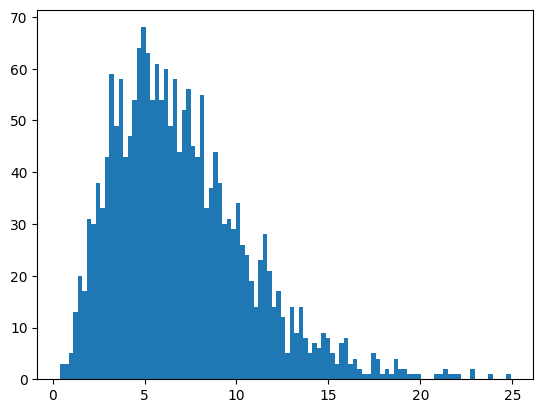

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(123)

m = 2000
boylar = rng.normal(loc=175, scale=10, size=(m,1))
yashlar = rng.uniform(18, 60, size=(m,1))
maashlar = rng.gamma(shape=3.5, scale=2, size=(m,1))

# mean = 3.5 * 2
# var = 3.5 * (2**2)
# std = np.sqrt(var)

plt.hist(maashlar, bins=100)
plt.show()

In [100]:
from sklearn.preprocessing import add_dummy_feature

X = np.hstack([boylar/100, yashlar/100])
X_b = add_dummy_feature(X)
y = maashlar.copy() / 10
X_b,y 

(array([[1.        , 1.65108786, 0.50989692],
        [1.        , 1.71322133, 0.53365526],
        [1.        , 1.87879253, 0.40733562],
        ...,
        [1.        , 1.61721291, 0.59492647],
        [1.        , 1.87379982, 0.50115299],
        [1.        , 1.87188795, 0.3580079 ]], shape=(2000, 3)),
 array([[1.37816364],
        [0.81455876],
        [0.22166009],
        ...,
        [0.63996853],
        [1.00447679],
        [0.47131357]], shape=(2000, 1)))

# Batch

$$
\nabla J(\theta) = \frac{1}{m} X^T (X \theta - y)
$$

$$
\theta_{yeni} = \theta_{kohne} - \eta \
 \nabla J(\theta)
$$

In [101]:
rng = np.random.default_rng(123)

n_epochs = 10000
eta = 0.2
theta = rng.normal(0, 1, (3,1))

for epoch in range(n_epochs):
	gradient = 1/m * X_b.T @ (X_b @ theta - y)
	theta = theta - eta * gradient # eta = learning rate

theta

array([[0.65717582],
       [0.0083812 ],
       [0.08470165]])

In [104]:
# 0.65717582 + 0.0083812 * 1.74 + 0.08470165 * 0.28 
X_test = np.array([
    [1.        , 1.74, 0.28],
])

X_test @ theta

array([[0.69547557]])

In [108]:
theta

array([[0.65717582],
       [0.0083812 ],
       [0.08470165]])

In [109]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y.ravel())
# lr.intercept_, lr.coef_
lr.predict(
    np.array([
    [1.74, 0.28],
])
)

array([0.6956173])

# stochastic

In [111]:
# batch = 2000 -> gradient -> theta update (10000 epoxa)
# stochastic = (1 -> gradient -> theta update (2000 təkrar)) (10000 epoxa)

$$
\nabla J_i(\theta) = X_i^T (X_i \theta - y_i)
$$

$$
\theta_{yeni} = \theta_{kohne} - \eta \ \nabla J_i(\theta_{kohne})
$$

In [194]:
rng = np.random.default_rng(123)

m = len(X_b)
n_epochs = 1000
n_iterations = 50
eta = 0.3
theta = rng.normal(0, 1, (3,1))

t0,t1 = 100,1000
def lr_scheduler(t):
    eta =  t0/ (t + t1)
    return eta

for epoch in range(n_epochs):
	for iteration in range(n_iterations):
		random_index = rng.integers(low=0, high=m)
		Xi = X_b[random_index: random_index+1]
		yi = y[random_index: random_index+1]

		gradient = Xi.T @ (Xi @ theta - yi)
		# eta = lr_scheduler(epoch*n_iterations + iteration)
		theta = theta - eta * gradient

theta

array([[ 0.54515969],
       [ 0.18342321],
       [-0.24777516]])

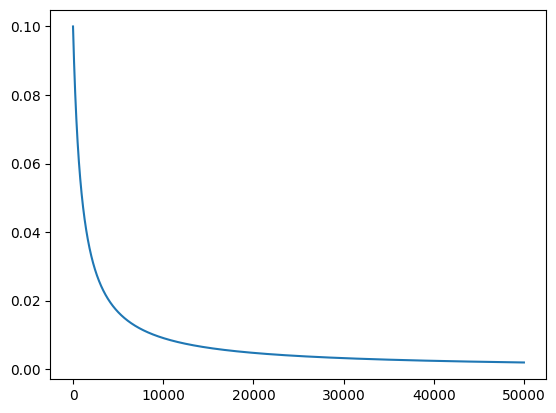

In [188]:
t0,t1 = 100,1000
def lr_scheduler(t):
    eta =  t0/ (t + t1)
    return eta

lr_scheduler(0)

etas = []

n_epochs = 100
n_iterations = 500
for epoch in range(n_epochs):
	for iteration in range(n_iterations):
		eta = lr_scheduler(epoch*n_iterations + iteration)
		etas.append(eta)
plt.plot(etas)
plt.show()

In [ ]:
t = 2*n_iterations + 0

1000

In [165]:
from sklearn.linear_model import SGDRegressor
sr = SGDRegressor()
sr.fit(X, y.ravel())
sr.intercept_, sr.coef_

(array([0.1832736]), array([0.27183428, 0.07231625]))

# mini batch

$$
\nabla J_{batch}(\theta) = \frac{1}{m_{batch}} \ X_{batch}^T (X_{batch} \theta - y_{batch})
$$

$$
\theta_{yeni} = \theta_{kohne} - \eta \ \nabla J_{batch}(\theta_{kohne})
$$

In [ ]:
rng = np.random.default_rng(123)

n_epochs = 500

m = len(X_b)
minibatch_size = 50
n_batches_per_epoch = np.ceil(m / minibatch_size).astype('int')

eta = 0.3
theta = rng.normal(0, 1, (3,1))

for epoch in range(n_epochs):
	shuffled_indices = rng.permutation(m)
	X_b_shuffled = X_b[shuffled_indices]
	y_shuffled = y[shuffled_indices]

	for iteration in range(n_batches_per_epoch):
		idx = iteration * minibatch_size
		Xi = X_b[idx: idx+minibatch_size]
		yi = y[idx: idx+minibatch_size]

		gradient = 1/ minibatch_size * Xi.T @ (Xi @ theta - yi)
		# eta = lr_scheduler(epoch*n_batches_per_epoch + iteration)
		theta = theta - eta * gradient

theta

array([[ 0.62991239],
       [-0.01072923],
       [ 0.05863981]])

In [273]:
sr = LinearRegression()
sr.fit(X, y.ravel())
sr.intercept_, sr.coef_

(np.float64(0.6653595619911143), array([0.00386665, 0.08403489]))